In [1]:
from pathlib import Path
import sys
ROOT = Path.cwd().resolve()
CANDIDATES = [ROOT] + list(ROOT.parents)
PROJECT_ROOT = next((p for p in CANDIDATES if (p / 'src').exists()), ROOT)
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

# 03 Mining / Clustering
Luat ket hop + phan cum coin + anomaly.

In [2]:
from src.data.loader import load_all_coins
from src.data.cleaner import clean_crypto_dataframe
from src.features.builder import build_features
from src.mining.association import mine_association_rules
from src.mining.clustering import cluster_coin_profiles
from src.mining.anomaly import detect_market_anomalies
feat_df = build_features(clean_crypto_dataframe(load_all_coins(str(PROJECT_ROOT / 'data' / 'raw'))))
rules = mine_association_rules(feat_df)
clusters, centroids = cluster_coin_profiles(feat_df)
anomalies = detect_market_anomalies(feat_df)
rules.head()

,antecedents,consequents,support,confidence,lift,leverage,conviction
392,"Litecoin__down__high_vol, Tron__down__high_vol",EOS__down__high_vol,0.082432,0.859155,4.957307,0.065804,5.869493
191,"Stellar__down__high_vol, Tron__down__high_vol",Cardano__down__high_vol,0.084122,0.824503,4.871317,0.066853,4.733669
365,"Iota__down__high_vol, Litecoin__down__high_vol",EOS__down__high_vol,0.089865,0.841772,4.857009,0.071363,5.224676
151,"ChainLink__down__high_vol, Stellar__down__high...",Cardano__down__high_vol,0.084797,0.820261,4.846255,0.067300,4.621953
459,"Stellar__up__high_vol, Tron__up__high_vol",EOS__up__high_vol,0.083446,0.845890,4.843009,0.066216,5.355526


In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

palette = {"stormcloud": "#4F6367", "beige": "#EEF5DB", "sunset": "#FE5F55"}
sns.set_theme(style="whitegrid")

In [4]:
rules.head(15)

,antecedents,consequents,support,confidence,lift,leverage,conviction
392,"Litecoin__down__high_vol, Tron__down__high_vol",EOS__down__high_vol,0.082432,0.859155,4.957307,0.065804,5.869493
191,"Stellar__down__high_vol, Tron__down__high_vol",Cardano__down__high_vol,0.084122,0.824503,4.871317,0.066853,4.733669
365,"Iota__down__high_vol, Litecoin__down__high_vol",EOS__down__high_vol,0.089865,0.841772,4.857009,0.071363,5.224676
151,"ChainLink__down__high_vol, Stellar__down__high...",Cardano__down__high_vol,0.084797,0.820261,4.846255,0.067300,4.621953
459,"Stellar__up__high_vol, Tron__up__high_vol",EOS__up__high_vol,0.083446,0.845890,4.843009,0.066216,5.355526
234,"Cardano__up__high_vol, EOS__up__high_vol",Tron__up__high_vol,0.089189,0.776471,4.788235,0.070562,3.748222
235,Tron__up__high_vol,"Cardano__up__high_vol, EOS__up__high_vol",0.089189,0.550000,4.788235,0.070562,1.966967
460,"EOS__up__high_vol, Stellar__up__high_vol",Tron__up__high_vol,0.083446,0.774295,4.774817,0.065970,3.712087
449,"Litecoin__up__high_vol, Tron__up__high_vol",EOS__up__high_vol,0.084797,0.833887,4.774286,0.067036,4.968534
457,"EOS__up__high_vol, NEM__up__high_vol",Tron__up__high_vol,0.080405,0.767742,4.734409,0.063422,3.607357


In [5]:
from src.mining.association import compare_rules_by_regime
rules_regime = compare_rules_by_regime(feat_df, min_support=0.08, min_confidence=0.55, min_lift=1.05, top_k=8)
rules_regime.head(20)

,regime,antecedents,consequents,support,confidence,lift,leverage,conviction
0,low_vol,USDCoin__up__low_vol,Tether__up__low_vol,0.151288,0.661885,1.740302,0.064356,1.832727
1,low_vol,USDCoin__down__low_vol,Tether__down__low_vol,0.155035,0.708779,1.352318,0.040391,1.634082
2,mid_vol,WrappedBitcoin__down__mid_vol,Bitcoin__down__mid_vol,0.087660,0.861925,2.740897,0.055678,4.964913
3,mid_vol,WrappedBitcoin__up__mid_vol,Bitcoin__up__mid_vol,0.099149,0.879245,2.353333,0.057018,5.187234
4,mid_vol,Dogecoin__up__mid_vol,Bitcoin__up__mid_vol,0.130638,0.589251,1.577154,0.047807,1.524979
5,mid_vol,Litecoin__up__mid_vol,Bitcoin__up__mid_vol,0.134894,0.575318,1.539859,0.047292,1.474945
6,mid_vol,Monero__up__mid_vol,Bitcoin__up__mid_vol,0.101277,0.558685,1.495343,0.033549,1.419357
7,high_vol,"Litecoin__down__high_vol, Tron__down__high_vol",EOS__down__high_vol,0.084429,0.859155,4.840074,0.066985,5.839689
8,high_vol,"Ethereum__down__high_vol, Tron__down__high_vol",Cardano__down__high_vol,0.080277,0.834532,4.813969,0.063601,4.995803
9,high_vol,"Stellar__down__high_vol, Tron__down__high_vol",Cardano__down__high_vol,0.086159,0.824503,4.756117,0.068044,4.710309


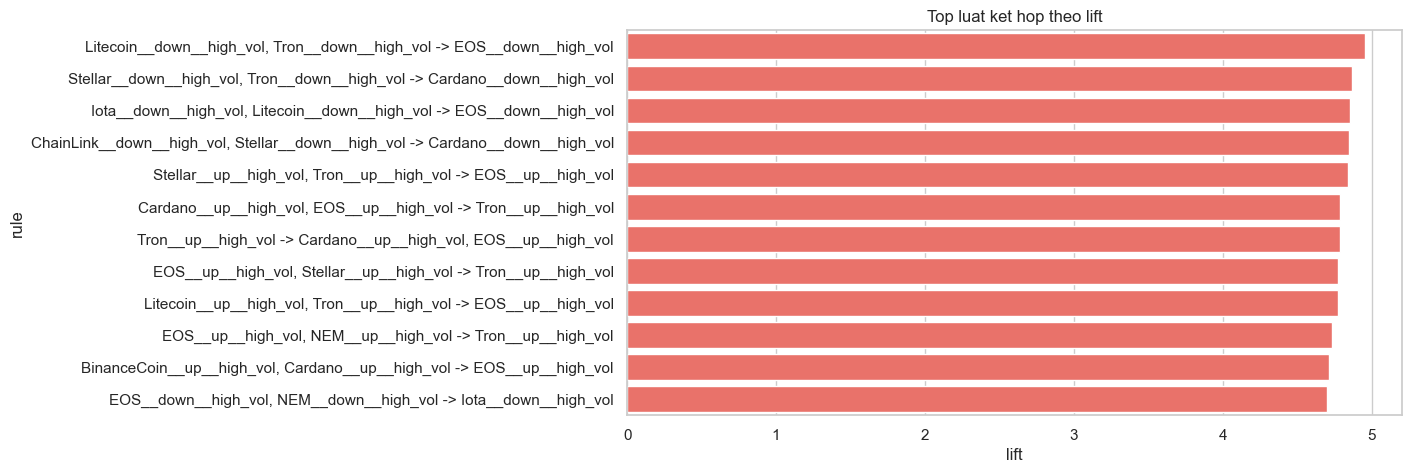

In [6]:
fig, ax = plt.subplots(figsize=(10, 5))
if len(rules) > 0:
    top = rules.head(12).copy()
    top["rule"] = top["antecedents"] + " -> " + top["consequents"]
    sns.barplot(data=top, x="lift", y="rule", color=palette["sunset"], ax=ax)
    ax.set_title("Top luat ket hop theo lift")
plt.show()

In [7]:
clusters.head(20)

,coin,avg_return_1d,avg_return_7d,avg_volatility_14,avg_volatility_30,avg_rsi,avg_hl_spread,cluster,profile_label
0,Aave,0.013613,0.093483,0.080731,0.082693,54.490000,0.135161,2,growth_high_beta
1,BinanceCoin,0.005867,0.043917,0.059087,0.062689,52.715220,0.085154,0,growth_high_beta
2,Bitcoin,0.002788,0.020059,0.036101,0.037455,53.934906,0.049448,3,growth_high_beta
3,Cardano,0.004775,0.049311,0.065084,0.067626,50.742531,0.090100,0,growth_high_beta
4,ChainLink,0.006216,0.042378,0.070593,0.072497,52.827538,0.109083,0,growth_high_beta
5,Cosmos,0.003884,0.025444,0.064986,0.066543,51.325233,0.097977,0,growth_high_beta
6,CryptocomCoin,0.003113,0.036003,0.055743,0.060471,50.908962,0.082113,0,growth_high_beta
7,Dogecoin,0.004168,0.046288,0.061638,0.067300,48.258494,0.082870,0,growth_high_beta
8,EOS,0.003151,0.023022,0.063248,0.065839,49.360779,0.085628,0,growth_high_beta
9,Ethereum,0.005332,0.040326,0.053439,0.055632,53.274869,0.074929,3,growth_high_beta


C:\Users\Admin\AppData\Local\Temp\ipykernel_17008\1114507631.py:2: UserWarning: The palette list has more values (4) than needed (2), which may not be intended.
  sns.scatterplot(


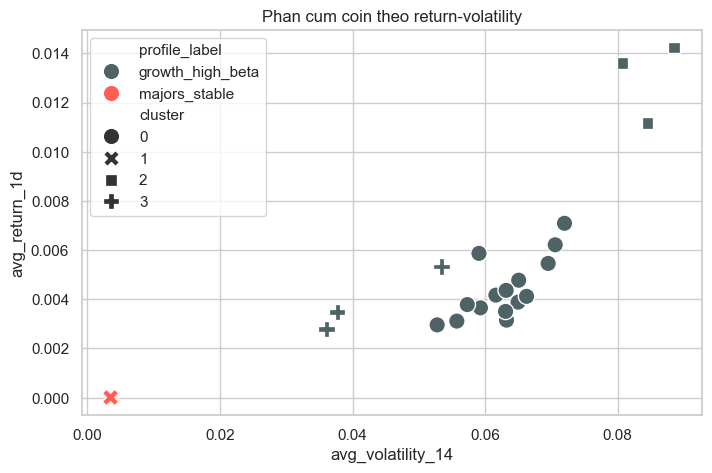

In [8]:
fig, ax = plt.subplots(figsize=(8, 5))
sns.scatterplot(
    data=clusters,
    x="avg_volatility_14",
    y="avg_return_1d",
    hue="profile_label",
    style="cluster",
    palette=[palette["stormcloud"], palette["sunset"], "#7A9E9F", "#A7C4BC"],
    s=140,
    ax=ax,
)
ax.set_title("Phan cum coin theo return-volatility")
plt.show()

In [9]:
centroids

,avg_return_1d,avg_return_7d,avg_volatility_14,avg_volatility_30,avg_rsi,avg_hl_spread,cluster,profile_label
0,0.004407,0.038124,0.062925,0.066062,50.414971,0.091016,0,growth_high_beta
1,0.000010,0.000029,0.003615,0.003737,49.564191,0.012288,1,majors_stable
2,0.013007,0.088171,0.084608,0.087180,54.637601,0.134325,2,growth_high_beta
3,0.003866,0.028065,0.042414,0.044021,54.190174,0.062315,3,growth_high_beta


In [10]:
anomaly_summary = anomalies.groupby("coin")["is_anomaly"].mean().sort_values(ascending=False).reset_index(name="anomaly_rate")
anomaly_summary.head(15)

,coin,anomaly_rate
0,Bitcoin,0.197297
1,Tether,0.117766
2,Ethereum,0.096759
3,Polkadot,0.048443
4,XRP,0.047536
5,Solana,0.045131
6,Cardano,0.039493
7,Dogecoin,0.038871
8,Uniswap,0.038314
9,BinanceCoin,0.034727


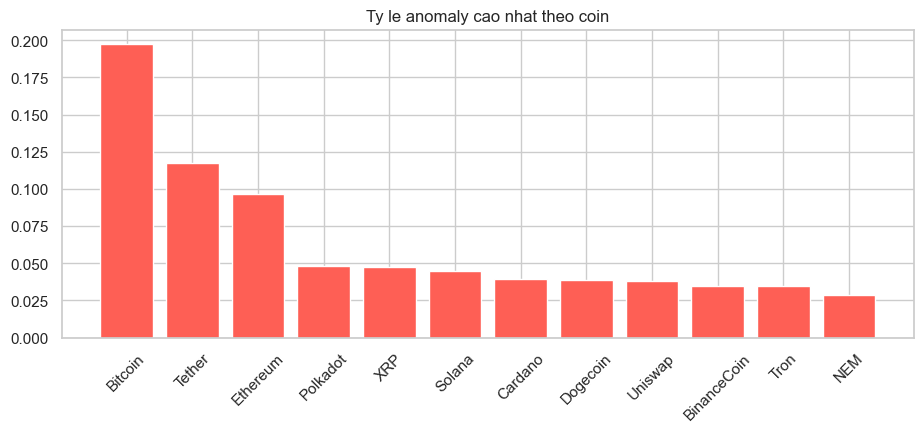

In [11]:
fig, ax = plt.subplots(figsize=(11, 4))
plot_df = anomaly_summary.head(12)
ax.bar(plot_df["coin"], plot_df["anomaly_rate"], color=palette["sunset"])
ax.set_title("Ty le anomaly cao nhat theo coin")
ax.tick_params(axis="x", rotation=45)
plt.show()

In [12]:
clusters.to_csv("../outputs/tables/notebook03_clusters.csv", index=False)
rules.to_csv("../outputs/tables/notebook03_rules.csv", index=False)
anomaly_summary.to_csv("../outputs/tables/notebook03_anomaly_summary.csv", index=False)